In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [3]:
import os
os.getcwd()


'c:\\Users\\radjema\\Desktop\\Predicting_Airline_Ticket_Prices\\notebook'

In [4]:
os.listdir()

['JB_CHEZE.ipynb', 'structure.txt']

In [13]:
import pandas as pd

df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv")
df.head()


C:\Users\radjema\AppData\Local\Temp\ipykernel_14844\3122517753.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Taxi_Trips_(2024-)_20251120.csv")


,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,e3742d2e5410f60a8d1c9b6ee277223dce58ef1f,ee2350d6534936ef855c7f72bfac42ee77b857396eff20...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,907,3.76,NaN,NaN,6.0,8.0,...,$0.00,$15.42,Mobile,Tac - Yellow Cab Association,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,d424ef338ee6b0abccb89bea24c02291e13ce0c2,beed6dfe6dd1428c7b3e478af254db9de420dcb71d8f15...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,806,2.08,NaN,NaN,28.0,32.0,...,$0.00,$11.97,Mobile,Blue Ribbon Taxi Association,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
2,41bf8c4e4e7fda387dc02bb60b3172c0ebd2f48b,deec568f18d18fb40292b918b82311ac8006ada6a8a1ff...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,"1,332",4.04,NaN,NaN,7.0,28.0,...,$0.00,$17.49,Mobile,City Service,41.922686,-87.649489,POINT (-87.6494887289 41.9226862843),41.874005,-87.663518,POINT (-87.6635175498 41.874005383)
3,10b94db76af57ea31739f90954674be92a3b6286,cd36cd2a179a2d9a40cdb19ad0df6dd0da9751496a9567...,11/01/2025 12:00:00 AM,11/01/2025 12:15:00 AM,789,3.09,NaN,NaN,33.0,8.0,...,$0.00,$40.50,Credit Card,City Service,41.857184,-87.620335,POINT (-87.6203346241 41.8571838585),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
4,41fea757d5e257d3ff0b5e1cb4a0a6d6fe01c459,f71223a469d78a2f65a090adc9d4fb5ae08dfc6694c650...,11/01/2025 12:00:00 AM,11/01/2025 12:00:00 AM,439,1.45,NaN,NaN,8.0,7.0,...,$0.00,$9.98,Mobile,Chicago Independents,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)


In [14]:
df.shape


(12233748, 23)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     object 
 1   Taxi ID                     object 
 2   Trip Start Timestamp        object 
 3   Trip End Timestamp          object 
 4   Trip Seconds                object 
 5   Trip Miles                  object 
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Fare                        object 
 11  Tips                        object 
 12  Tolls                       object 
 13  Extras                      object 
 14  Trip Total                  object 
 15  Payment Type                object 
 16  Company                     object 
 17  Pickup Centroid Latitude    float64
 18  Pickup Centroid Longitude   float64
 19  Pickup Centroid Loc

In [16]:
df.isna().sum().sort_values(ascending=False)


Dropoff Census Tract          6988028
Pickup Census Tract           6820182
Dropoff Community Area        1112901
Dropoff Centroid Longitude    1044112
Dropoff Centroid  Location    1044112
Dropoff Centroid Latitude     1044112
Pickup Community Area          340545
Pickup Centroid Location       334109
Pickup Centroid Latitude       334109
Pickup Centroid Longitude      334109
Trip Total                      28149
Fare                            28149
Extras                          28149
Tolls                           28149
Tips                            28149
Trip Seconds                     2313
Trip End Timestamp                132
Trip Miles                        101
Taxi ID                            11
Trip ID                             0
Trip Start Timestamp                0
Payment Type                        0
Company                             0
dtype: int64

In [17]:
num_price_cols = ["Trip Total", "Fare", "Tips", "Tolls", "Extras"]

for col in num_price_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # retirer les virgules thousands
        .str.replace("$", "", regex=False)   # retirer éventuels $
        .str.strip()                         # retirer espaces
        .replace("", pd.NA)                  # convertir vide -> NA
    )

    # Conversion finale en float
    df[col] = pd.to_numeric(df[col], errors="coerce")

Nettoyage de Trip Total...
Nettoyage de Fare...
Nettoyage de Tips...
Nettoyage de Tolls...
Nettoyage de Extras...


In [18]:
df[num_price_cols].info()
df[num_price_cols].head()
df[num_price_cols].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Trip Total  float64
 1   Fare        float64
 2   Tips        float64
 3   Tolls       float64
 4   Extras      float64
dtypes: float64(5)
memory usage: 466.7 MB


,Trip Total,Fare,Tips,Tolls,Extras
count,1.220560e+07,1.220560e+07,1.220560e+07,1.220560e+07,1.220560e+07
mean,2.796973e+01,2.278115e+01,2.839164e+00,3.122287e-02,2.086876e+00
std,3.708475e+01,3.254903e+01,4.271552e+00,4.105155e+00,9.168591e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.025000e+01,8.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.860000e+01,1.565000e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.231000e+01,3.425000e+01,4.000000e+00,0.000000e+00,2.000000e+00
max,9.999750e+03,9.999750e+03,4.000000e+02,5.550000e+03,5.559500e+03


Les variables financières (Trip Total, Fare, Tips, Extras, Tolls) ainsi que les variables de distance (Trip Miles) et de durée (Trip Seconds) étaient initialement au format texte, à cause de symboles comme `$` ou `,`.

Dans cette cellule, je convertis chacune de ces colonnes en `float` afin de pouvoir effectuer des calculs et des statistiques.  
Cette étape est indispensable pour l’analyse et la modélisation.

In [19]:
df[["Trip Total", "Fare"]].sample(10)


,Trip Total,Fare
12032999,10.75,7.75
5371773,10.50,8.00
1009544,61.25,45.00
5542372,57.70,44.00
10738853,9.00,8.00
7914596,12.00,8.50
98486,5.50,5.00
11258690,9.00,9.00
12077085,11.50,5.50
2545592,59.10,43.75


In [20]:
num_trip_cols = ["Trip Miles", "Trip Seconds"]

for col in num_trip_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")


Nettoyage de Trip Miles...
Nettoyage de Trip Seconds...


In [21]:
df[num_trip_cols].info()
df[num_trip_cols].describe()
df[num_trip_cols].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Trip Miles    float64
 1   Trip Seconds  float64
dtypes: float64(2)
memory usage: 186.7 MB


,Trip Miles,Trip Seconds
0,3.76,907.0
1,2.08,806.0
2,4.04,1332.0
3,3.09,789.0
4,1.45,439.0


In [22]:
geo_cols = ["Pickup Community Area", "Dropoff Community Area"]

for col in geo_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)  # si jamais il y avait des milliers
        .str.strip()
        .replace("", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")


Nettoyage de Pickup Community Area...
Nettoyage de Dropoff Community Area...


###  Nettoyage des zones géographiques simplifiées (Community Areas)

Les colonnes `Pickup Community Area` et `Dropoff Community Area` représentent 
les zones administratives de Chicago (1 à 77) où commencent et se terminent les trajets.  
Ces deux variables sont essentielles pour capturer l’effet géographique sur le prix des courses, 
tout en évitant la complexité excessive des coordonnées GPS ou des Census Tracts.

Cependant, plusieurs problèmes étaient présents :
- des valeurs manquantes importantes (environ 340k pour pickup et 1.1M pour dropoff),
- des formats incohérents (valeurs sous forme de texte, parfois avec des virgules),
- des zones inconnues lorsque le taxi sort de Chicago ou lorsque la donnée est anonymisée.

Dans cette étape, je :
1. Nettoie le format (strip, suppression de caractères parasites) ;
2. Convertis les colonnes en type numérique (`float64`) ;
3. Remplace les valeurs manquantes par **-1**, une nouvelle catégorie indiquant 
   une zone géographique inconnue (“Unknown Area”).

Cette approche permet de conserver tous les trajets tout en rendant les données cohérentes 
et exploitables pour l'analyse et la modélisation.


In [23]:
df[geo_cols].info()
df[geo_cols].describe()
df[geo_cols].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Pickup Community Area   float64
 1   Dropoff Community Area  float64
dtypes: float64(2)
memory usage: 186.7 MB


,Pickup Community Area,Dropoff Community Area
0,6.0,8.0
1,28.0,32.0
2,7.0,28.0
3,33.0,8.0
4,8.0,7.0


In [24]:
date_cols = ["Trip Start Timestamp", "Trip End Timestamp"]

for col in date_cols:
    print(f"Conversion de {col} en datetime...")
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].info()
df[date_cols].head()


Conversion de Trip Start Timestamp en datetime...


C:\Users\radjema\AppData\Local\Temp\ipykernel_14844\855099599.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


Conversion de Trip End Timestamp en datetime...


C:\Users\radjema\AppData\Local\Temp\ipykernel_14844\855099599.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Trip Start Timestamp  datetime64[ns]
 1   Trip End Timestamp    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 186.7 MB


,Trip Start Timestamp,Trip End Timestamp
0,2025-11-01,2025-11-01 00:15:00
1,2025-11-01,2025-11-01 00:15:00
2,2025-11-01,2025-11-01 00:15:00
3,2025-11-01,2025-11-01 00:15:00
4,2025-11-01,2025-11-01 00:00:00


###  Conversion des colonnes temporelles en format datetime

Les colonnes `Trip Start Timestamp` et `Trip End Timestamp` sont fournies dans le dataset
au format texte (string). Pour pouvoir analyser correctement la dimension temporelle des trajets 
et créer de futures variables (heure, jour de la semaine, période de la journée, etc.), 
je convertis ces deux colonnes en type `datetime64`.

Cette conversion permet :
- d’extraire facilement des informations temporelles (heure, jour, mois, année),
- d'étudier les heures de pointe et les comportements selon les périodes de la journée,
- de vérifier la cohérence entre la durée enregistrée (`Trip Seconds`) et la différence entre les timestamps.

Le paramètre `errors="coerce"` permet de transformer automatiquement les dates illisibles en `NaT`
afin d’éviter les erreurs au chargement. Les rares valeurs manquantes seront ensuite traitées lors du nettoyage.


In [26]:
df["Trip Start Timestamp"].dt.hour.value_counts().head(10)


Trip Start Timestamp
17    878978
16    856594
15    845693
14    821699
18    803801
13    801083
12    779051
11    729196
9     705945
10    690614
Name: count, dtype: int64

In [27]:
cat_cols = ["Payment Type", "Company"]

for col in cat_cols:
    print(f"Nettoyage de {col}...")
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()          # enlever espaces au début/fin
    )
    # On remplace les valeurs "nan" texte par NA réelle
    df[col] = df[col].replace(["nan", "NaN", "None", ""], pd.NA)
    df[col] = df[col].astype("category")

df[cat_cols].info()
for col in cat_cols:
    print(f"\nValeurs les plus fréquentes pour {col} :")
    print(df[col].value_counts(dropna=False).head(10))


Nettoyage de Payment Type...
Nettoyage de Company...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 2 columns):
 #   Column        Dtype   
---  ------        -----   
 0   Payment Type  category
 1   Company       category
dtypes: category(2)
memory usage: 23.3 MB

Valeurs les plus fréquentes pour Payment Type :
Payment Type
Credit Card    4638710
Cash           3233359
Mobile         2438598
Prcard         1419565
Unknown         462386
No Charge        34028
Dispute           7062
Prepaid             40
Name: count, dtype: int64

Valeurs les plus fréquentes pour Company :
Company
Flash Cab                            2553158
Taxi Affiliation Services            1666116
Taxicab Insurance Agency Llc         1417640
Sun Taxi                             1327798
City Service                         1196014
Chicago Independents                  746495
5 Star Taxi                           602775
Blue Ribbon Taxi Association          51

###  Nettoyage des variables catégorielles (Payment Type, Company)

Les colonnes catégorielles contenaient des espaces parasites, des chaînes 'nan' et d'autres incohérences.  
Je nettoie ces valeurs (strip, remplacement des faux NA) puis je convertis les colonnes en `category`, ce qui :

- réduit la mémoire utilisée,
- prépare les données pour les futures étapes d’encodage,
- facilite l’analyse des distributions de modalités.

In [29]:
for col in df.columns:
    print(f"'{col}'")


'Trip ID'
'Taxi ID'
'Trip Start Timestamp'
'Trip End Timestamp'
'Trip Seconds'
'Trip Miles'
'Pickup Census Tract'
'Dropoff Census Tract'
'Pickup Community Area'
'Dropoff Community Area'
'Fare'
'Tips'
'Tolls'
'Extras'
'Trip Total'
'Payment Type'
'Company'
'Pickup Centroid Latitude'
'Pickup Centroid Longitude'
'Pickup Centroid Location'
'Dropoff Centroid Latitude'
'Dropoff Centroid Longitude'
'Dropoff Centroid  Location'


In [30]:
cols_to_drop = [
    "Pickup Census Tract",
    "Dropoff Census Tract",
    "Pickup Centroid Latitude",
    "Pickup Centroid Longitude",
    "Pickup Centroid Location",
    "Dropoff Centroid Latitude",
    "Dropoff Centroid Longitude",
    "Dropoff Centroid  Location"   # ⚠️ double espace ici !
]

df = df.drop(columns=cols_to_drop)


###  Suppression des colonnes géographiques détaillées

Le dataset contient plusieurs colonnes géographiques très précises 
(`Census Tract`, `Centroid Latitude/Longitude`, `Centroid Location`).  
Ces variables posent plusieurs problèmes :

- elles contiennent un très grand nombre de valeurs manquantes ;
- elles sont souvent vides pour les trajets hors de Chicago ;
- leur niveau de précision (tract, centroid) est trop élevé pour notre objectif ;
- elles n'apportent pas d'information utile supplémentaire par rapport 
  aux variables plus simples comme `Pickup Community Area` et `Dropoff Community Area`.

Dans cette étape, je supprime donc ces colonnes afin de :
- réduire la taille du dataset,
- éliminer du bruit inutile,
- simplifier l'analyse exploratoire,
- et garder uniquement les informations géographiques réellement pertinentes.

Les Community Areas seront conservées, car elles décrivent les zones de prise en charge 
et de dépose de manière suffisamment informative et cohérente pour la modélisation.


In [31]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12233748 entries, 0 to 12233747
Data columns (total 15 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Trip ID                 object        
 1   Taxi ID                 object        
 2   Trip Start Timestamp    datetime64[ns]
 3   Trip End Timestamp      datetime64[ns]
 4   Trip Seconds            float64       
 5   Trip Miles              float64       
 6   Pickup Community Area   float64       
 7   Dropoff Community Area  float64       
 8   Fare                    float64       
 9   Tips                    float64       
 10  Tolls                   float64       
 11  Extras                  float64       
 12  Trip Total              float64       
 13  Payment Type            category      
 14  Company                 category      
dtypes: category(2), datetime64[ns](2), float64(9), object(2)
memory usage: 1.2+ GB


(12233748, 15)

In [32]:
df.isna().sum().sort_values(ascending=False)


Dropoff Community Area    1112901
Pickup Community Area      340545
Trip Total                  28149
Tolls                       28149
Tips                        28149
Fare                        28149
Extras                      28149
Trip Seconds                 2313
Trip End Timestamp            132
Trip Miles                    101
Taxi ID                        11
Trip ID                         0
Trip Start Timestamp            0
Payment Type                    0
Company                         0
dtype: int64

In [33]:
df = df.dropna(subset=[
    "Trip Total",
    "Trip Miles",
    "Trip Seconds",
    "Fare",
    "Tips",
    "Tolls",
    "Extras"
])


In [34]:
df["Pickup Community Area"] = df["Pickup Community Area"].fillna(-1)
df["Dropoff Community Area"] = df["Dropoff Community Area"].fillna(-1)


Dans cette étape, je traite les valeurs manquantes des variables importantes :

Les colonnes liées au prix (Trip Total, Fare, Tips, Tolls, Extras)

Les colonnes de distance et durée (Trip Miles, Trip Seconds)

Comme ces variables sont essentielles pour la modélisation et que les valeurs manquantes représentent moins de 0,3 % du dataset, j’ai choisi de supprimer ces lignes.
Il n’est pas possible d’imputer correctement un prix, une distance ou une durée, donc la suppression est la solution la plus fiable.

Pour les colonnes géographiques simples (Pickup Community Area et Dropoff Community Area), les valeurs manquantes représentent des trajets hors Chicago ou anonymisés.
Au lieu de supprimer plus d’un million de lignes, j’impute ces NA avec une nouvelle catégorie –1, qui représentera une zone inconnue (“Unknown Area”).

Cette approche permet :

de conserver un maximum de données,

d’éviter de perdre des trajets valides,

et de garder une information utile pour la modélisation.

In [35]:
df.isna().sum().sort_values(ascending=False)


Taxi ID                   11
Trip ID                    0
Trip Start Timestamp       0
Trip End Timestamp         0
Trip Seconds               0
Trip Miles                 0
Pickup Community Area      0
Dropoff Community Area     0
Fare                       0
Tips                       0
Tolls                      0
Extras                     0
Trip Total                 0
Payment Type               0
Company                    0
dtype: int64

In [36]:
row_counts = (
    df.count()
      .to_frame(name="nb_valid_rows")
      .assign(pct_valid=lambda x: x["nb_valid_rows"] / len(df) * 100)
      .sort_values("nb_valid_rows", ascending=False)
)

row_counts


,nb_valid_rows,pct_valid
Trip ID,12204111,100.00000
Trip Start Timestamp,12204111,100.00000
Trip End Timestamp,12204111,100.00000
Trip Miles,12204111,100.00000
Trip Seconds,12204111,100.00000
Pickup Community Area,12204111,100.00000
Dropoff Community Area,12204111,100.00000
Extras,12204111,100.00000
Fare,12204111,100.00000
Tips,12204111,100.00000


In [43]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df["Trip Total"].describe()


count   12204111.00
mean          27.96
std           36.58
min            0.00
25%           10.25
50%           18.60
75%           42.31
max         9999.75
Name: Trip Total, dtype: float64

<Axes: ylabel='Frequency'>

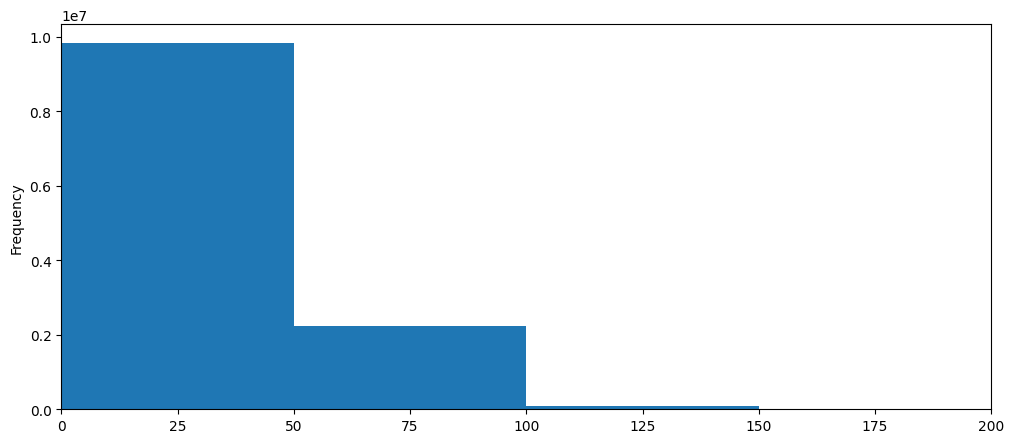

In [39]:
df["Trip Total"].plot(kind="hist", bins=200, figsize=(12,5), xlim=(0,200))


In [40]:
df[df["Trip Total"] > 300].shape


(4496, 15)

In [41]:
df[df["Trip Total"] > 500].shape


(2387, 15)

In [42]:
df[df["Trip Total"] > 1000].shape


(1153, 15)

In [45]:
df[df["Trip Total"] == 0].shape


(29459, 15)

In [46]:
df = df[df["Trip Total"] <= 300]


In [47]:
df = df[df["Trip Total"] > 0]


In [48]:
df["Trip Total"].describe()


count   12170156.00
mean          27.67
std           23.22
min            0.01
25%           10.41
50%           18.65
75%           42.50
max          300.00
Name: Trip Total, dtype: float64

In [50]:
df.to_parquet("../data/taxi_clean.parquet", index=False)



In [51]:
df_test = pd.read_parquet("../data/taxi_clean.parquet")
df_test.head()


,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company
0,e3742d2e5410f60a8d1c9b6ee277223dce58ef1f,ee2350d6534936ef855c7f72bfac42ee77b857396eff20...,2025-11-01,2025-11-01 00:15:00,907.00,3.76,6.00,8.00,11.56,3.36,0.00,0.00,15.42,Mobile,Tac - Yellow Cab Association
1,d424ef338ee6b0abccb89bea24c02291e13ce0c2,beed6dfe6dd1428c7b3e478af254db9de420dcb71d8f15...,2025-11-01,2025-11-01 00:15:00,806.00,2.08,28.00,32.00,11.47,0.00,0.00,0.00,11.97,Mobile,Blue Ribbon Taxi Association
2,41bf8c4e4e7fda387dc02bb60b3172c0ebd2f48b,deec568f18d18fb40292b918b82311ac8006ada6a8a1ff...,2025-11-01,2025-11-01 00:15:00,1332.00,4.04,7.00,28.00,16.99,0.00,0.00,0.00,17.49,Mobile,City Service
3,10b94db76af57ea31739f90954674be92a3b6286,cd36cd2a179a2d9a40cdb19ad0df6dd0da9751496a9567...,2025-11-01,2025-11-01 00:15:00,789.00,3.09,33.00,8.00,40.00,0.00,0.00,0.00,40.50,Credit Card,City Service
4,41fea757d5e257d3ff0b5e1cb4a0a6d6fe01c459,f71223a469d78a2f65a090adc9d4fb5ae08dfc6694c650...,2025-11-01,2025-11-01 00:00:00,439.00,1.45,8.00,7.00,9.48,0.00,0.00,0.00,9.98,Mobile,Chicago Independents


In [52]:
df_test.duplicated().sum()


np.int64(0)

In [53]:
df_test["Trip ID"].duplicated().sum()


np.int64(0)

In [54]:
df_test["Trip ID"].nunique(), len(df_test)


(12170156, 12170156)

Aucun doublon n'est présent dans le dataset.
Chaque trajet est correctement identifié de manière unique.


In [55]:
df_test["Trip Miles"].describe()


count   12170156.00
mean           6.70
std            7.34
min            0.00
25%            1.08
50%            3.25
75%           11.80
max         3397.80
Name: Trip Miles, dtype: float64

In [56]:
df_test[df_test["Trip Miles"] > 50].shape
df_test[df_test["Trip Miles"] > 100].shape
df_test[df_test["Trip Miles"] > 200].shape


(33, 15)

In [57]:
df_test[df_test["Trip Seconds"] > 20000].shape
df_test[df_test["Trip Seconds"] > 40000].shape
df_test[df_test["Trip Seconds"] > 100000].shape


(0, 15)

In [58]:
df_test = df_test[df_test["Trip Miles"] <= 50]


In [59]:
df_test["Trip Seconds"].describe()


count   12165270.00
mean        1247.43
std         1588.87
min            0.00
25%          480.00
50%          928.00
75%         1695.00
max        86400.00
Name: Trip Seconds, dtype: float64

In [60]:
df_test[df_test["Trip Seconds"] == 0].shape
df_test[df_test["Trip Seconds"] > 20000].shape
df_test[df_test["Trip Seconds"] > 40000].shape
df_test[df_test["Trip Seconds"] >= 86400].shape


(1, 15)